In [2]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.utils import pad_sequences
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

In [3]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

Cargamos los datos

In [4]:
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/viaje-al-centro-de-la-tierra/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [5]:
article_text[:1000]

' el domingo 24 de mayo de 1863, mi tío, el profesor lidenbrock, entró \r\nrápidamente a su hogar, situado en el número 19 de la könig‑strasse, una\r\n de las calles más tradicionales del barrio antiguo de hamburgo. marta, su excelente criada, se preocupó sobremanera, creyendo que se \r\nhabía retrasado, pues apenas empezaba a cocinar la comida en el \r\nhornillo. “bueno” —pensé para mí—, “si mi tío viene con hambre, se va a armar \r\nla de san quintín; porque no conozco a otro hombre de menos paciencia”. —¡tan temprano y ya está aquí el señor lidenbrock! —exclamó la pobre marta, con arrebol, entreabriendo la puerta del comedor. —sí, marta; pero tú no tienes la culpa de que la comida no esté lista\r\n todavía, porque es temprano, aún no son las dos. acaba de dar la media \r\nhora en san miguel. —¿y por qué ha venido tan pronto el señor lidenbrock? —él lo explicará, seguramente. —¡ahí viene! yo me escapo. señor axel, cálmelo usted, por favor. y la excelente marta se retiró presurosa a s

Tamaño del contexto

In [6]:
max_context_size = 100

In [7]:
chars_vocab = set(article_text)

In [8]:
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

Tokenizar

In [9]:
tokenized_text = [char2idx[ch] for ch in article_text]

In [10]:
tokenized_text[:1000]

[63,
 19,
 61,
 63,
 17,
 75,
 11,
 13,
 32,
 58,
 75,
 63,
 59,
 60,
 63,
 17,
 19,
 63,
 11,
 68,
 16,
 75,
 63,
 17,
 19,
 63,
 8,
 34,
 4,
 52,
 6,
 63,
 11,
 13,
 63,
 10,
 72,
 75,
 6,
 63,
 19,
 61,
 63,
 49,
 70,
 75,
 54,
 19,
 3,
 75,
 70,
 63,
 61,
 13,
 17,
 19,
 32,
 37,
 70,
 75,
 56,
 7,
 6,
 63,
 19,
 32,
 10,
 70,
 31,
 63,
 76,
 43,
 70,
 55,
 49,
 13,
 17,
 68,
 11,
 19,
 32,
 10,
 19,
 63,
 68,
 63,
 3,
 74,
 63,
 42,
 75,
 58,
 68,
 70,
 6,
 63,
 3,
 13,
 10,
 74,
 68,
 17,
 75,
 63,
 19,
 32,
 63,
 19,
 61,
 63,
 32,
 67,
 11,
 19,
 70,
 75,
 63,
 8,
 22,
 63,
 17,
 19,
 63,
 61,
 68,
 63,
 7,
 26,
 32,
 13,
 58,
 39,
 3,
 10,
 70,
 68,
 3,
 3,
 19,
 6,
 63,
 74,
 32,
 68,
 76,
 43,
 63,
 17,
 19,
 63,
 61,
 68,
 3,
 63,
 56,
 68,
 61,
 61,
 19,
 3,
 63,
 11,
 55,
 3,
 63,
 10,
 70,
 68,
 17,
 13,
 56,
 13,
 75,
 32,
 68,
 61,
 19,
 3,
 63,
 17,
 19,
 61,
 63,
 37,
 68,
 70,
 70,
 13,
 75,
 63,
 68,
 32,
 10,
 13,
 58,
 74,
 75,
 63,
 17,
 19,
 63,
 42,
 68,
 11,


División entre training y val

In [11]:
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [12]:
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [13]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [14]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [15]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

In [16]:
vocab_size = len(chars_vocab)

Modelo

In [16]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 78)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        55,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 78)       │        15,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,478 (279.21 KB)

 Trainable params: 71,478 (279.21 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True

In [18]:
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

Epoch 1/20
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - loss: 2.4475
 mean perplexity: 6.4204159369324865 

Saved new model!
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 597s 389ms/step - loss: 2.4474
Epoch 2/20
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - loss: 1.9528
 mean perplexity: 5.582189189309034 

Saved new model!
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 603s 396ms/step - loss: 1.9528
Epoch 3/20
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - loss: 1.8510
 mean perplexity: 5.311451547383709 

Saved new model!
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 607s 386ms/step - loss: 1.8510
Epoch 4/20
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - loss: 1.8049
 mean perplexity: 5.1231118172338 

Saved new model!
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 634s 394ms/step - loss: 1.8049
Epoch 5/20
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - loss: 1.7800
 mean perplexity: 4.997887876360156 

Saved new model!
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 607s 399ms/step - loss: 1.7800
Epoch 6/20
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - los

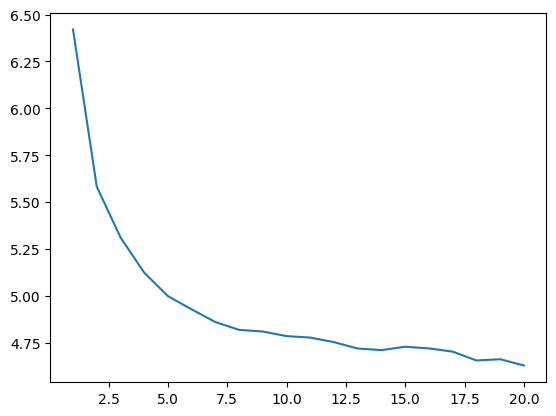

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

In [21]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model('my_model.keras')

In [22]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5017a6703857714259.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://5017a6703857714259.gradio.live


In [18]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [24]:
input_text='habia una vez'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'habia una vez de la cabeza de la cabeza de '

In [19]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [20]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [27]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=20,input="habia una vez")

In [28]:
salidas[0]

array([64, 31, 57, 56, 31, 49, 13, 60, 31, 49, 21, 38, 28, 49,  7, 13, 38,
       49, 38,  5, 49, 46, 25, 22, 29, 38, 10, 22, 25, 49, 52, 38, 49])

In [29]:
# veamos las salidas
decode(salidas[0])

'habia una vez que el profesor de '

Greedy Search

In [21]:
def greedy_search(model, num_words, input, temp=1, mode='det'):

    # encode input
    encoded = encode(input)
    if len(encoded.shape) == 2:
        generated = list(encoded[0])
    else:
        generated = list(encoded)

    # eliminar posibles ceros de padding al inicio
    generated = [tok for tok in generated if tok != 0]

    for _ in range(num_words):
        input_seq = np.array([generated])
        y_hat = model.predict(input_seq, verbose=0)[0, -1, :]

        if mode == 'det':
            next_token = int(np.argmax(y_hat))
        else:
            y_hat = np.exp(np.log(y_hat + 1e-8) / temp)
            y_hat = y_hat / np.sum(y_hat)
            next_token = int(np.random.choice(len(y_hat), p=y_hat))

        generated.append(next_token)

    # devolver input inicial + tokens generados
    return np.array(generated, dtype=int)

In [60]:
salidas = greedy_search(model,num_words=20,input="habia una vez")

In [61]:
decode(salidas)

'habia una vez de la cabeza de la '

LSTM

In [22]:
model = Sequential()
model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"), input_shape=(None,1)))
model.add(LSTM(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 78)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 200)      │       223,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 78)       │        15,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,878 (933.12 KB)

 Trainable params: 238,878 (933.12 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

Epoch 1/20
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 2.6784
 mean perplexity: 8.17798463540398 

Saved new model!
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2271s 1s/step - loss: 2.6782
Epoch 2/20
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 2.1140